#### Tissera Ana Paula - `Notebook TP3`

In [222]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Imports

In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os

In [224]:
SEED = 42

In [225]:
X_images = np.load("data/X_images.npy")
y_images = np.load("data/y_images.npy")


In [226]:
print("Forma de X:", X_images.shape)
print("Forma de y:", y_images.shape)
print("Etiquetas únicas:", np.unique(y_images))

Forma de X: (5000, 784)
Forma de y: (5000,)
Etiquetas únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


### Visualización de imágenes

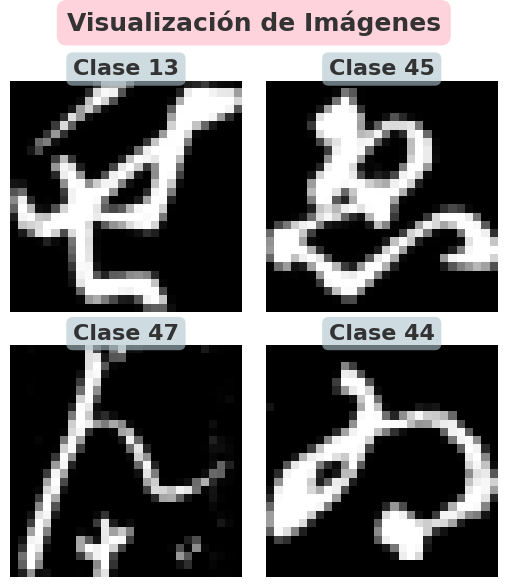

In [227]:
from src.plot import plot_images

name_map = {i: f"Clase {i}" for i in np.unique(y_images)}

# # Llamada al plot
# plot_images(
#     X_images, y_images,
#     indices=list(range(8)),       # muestra las primeras 12
#     n_cols=4,                      # 4 columnas → 3 filas
#     cmap='gray',
#     figsize_scale=2.5,
#     title_bg_color='#AEDFF7',      
#     title_color='#333333',
#     title_alpha=0.6,
#     suptitle="Ejemplo de Imágenes",
#     suptitle_bg='#FCC9B9',         
#     suptitle_color='#333333',
#     suptitle_alpha=0.6,
#     name_map=name_map
# )

np.random.seed(SEED)
clases = np.unique(y_images)
clases_seleccion = np.random.choice(clases, size=4, replace=False)
indices = []
for cl in clases_seleccion:
    idxs_cl = np.where(y_images == cl)[0]
    indices.append(int(np.random.choice(idxs_cl)))

name_map = {i: f"Clase {i}" for i in np.unique(y_images)}

plot_images(
    X_images, y_images,
    indices=indices,         
    n_cols=2,               # número de imágenes     
    suptitle="Visualización de Imágenes",
    name_map=name_map,
    random_seed=SEED
)

In [228]:
print("▶ X:", type(X_images), "shape =", X_images.shape, "dtype =", X_images.dtype)
print("▶ y:", type(y_images), "shape =", y_images.shape, "dtype =", y_images.dtype)

# Si X está aplanado, chequeá min/max
print("▶ X min/max:", X_images.min(), "/", X_images.max())

▶ X: <class 'numpy.ndarray'> shape = (5000, 784) dtype = float32
▶ y: <class 'numpy.ndarray'> shape = (5000,) dtype = int64
▶ X min/max: 0.0 / 255.0


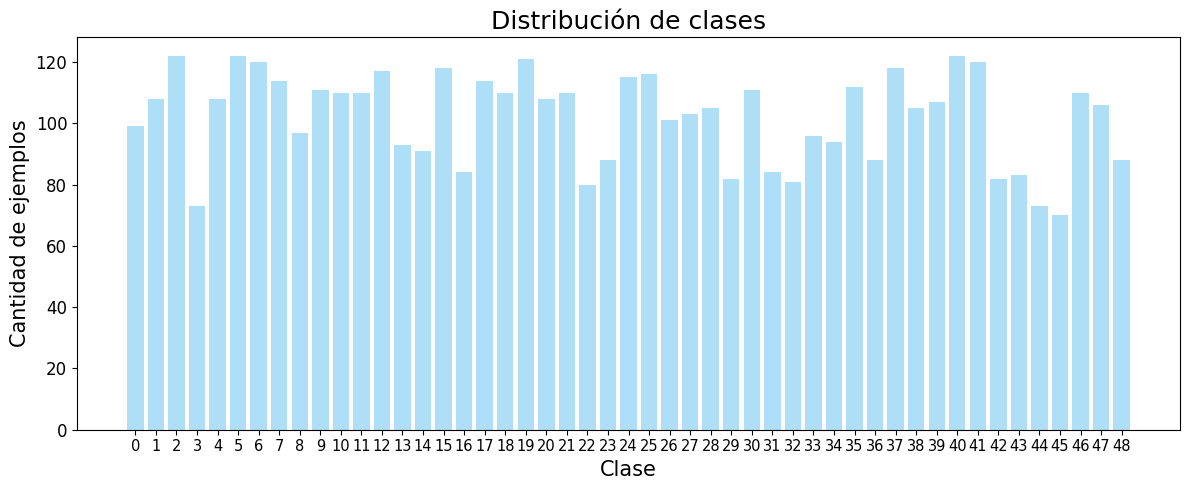

In [229]:
from src.plot import plot_class_distribution
plot_class_distribution(y_images, name_map=name_map, figsize=(12, 5), color='#AEDFF7')

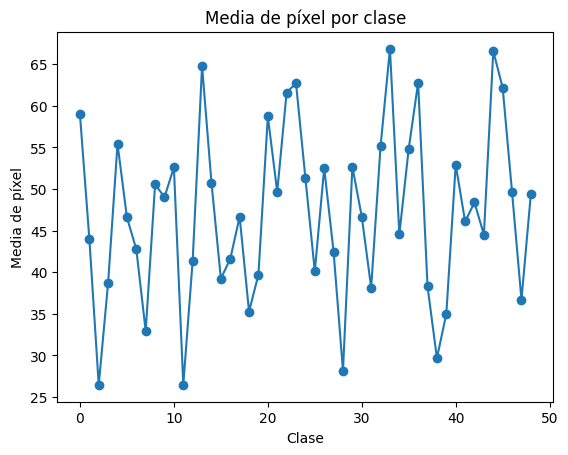

In [230]:
medias = [X_images[y_images==cl].mean() for cl in clases]
plt.plot(clases, medias, marker='o')
plt.xlabel("Clase")
plt.ylabel("Media de píxel")
plt.title("Media de píxel por clase")
plt.show()

In [231]:
print("Media de píxeles en todo X:", X_images.mean())
print("Desviación estándar de píxeles:", X_images.std())

Media de píxeles en todo X: 46.525486
Desviación estándar de píxeles: 87.565414


#### División del dataset


In [232]:
from src.data_splitting import split_data

X_dev, X_test, y_dev, y_test = split_data(X_images, y_images, ratio=0.2, random_seed=SEED)

X_train, X_val, y_train, y_val = split_data(X_dev, y_dev, ratio=0.2, random_seed=SEED)


#### Normalización

In [233]:
X_train = X_train.astype(np.float32) / 255.0
X_val   = X_val.astype(np.float32)   / 255.0
X_test  = X_test.astype(np.float32)  / 255.0
X_dev   = X_dev.astype(np.float32)   / 255.0

out_dir = "data/processed"
os.makedirs(out_dir, exist_ok=True)

np.savez_compressed(os.path.join(out_dir, "train.npz"), X=X_train, y=y_train)
np.savez_compressed(os.path.join(out_dir, "val.npz"),   X=X_val,   y=y_val)
np.savez_compressed(os.path.join(out_dir, "test.npz"),  X=X_test,  y=y_test)


Entrenar una red neuronal con 2 capas ocultas, con 100 y 80 nodos respectiva-
mente, y graficar la evolución de la función de costo (cross-entropy) sobre los
conjuntos de entrenamiento y validación a lo largo de las épocas. Llamaremos a
este modelo M0.
Reportar las siguientes métricas de performance, sobre los conjuntos de entrena-
miento y validación, para el modelo base entrenado:
•Accuracy
•Cross-Entropy
•Matriz de Confusión
a parte (la idea es que sea en otro archivo) implementá las métricas. 

depsués al mostrar las métricas quiero usar from IPython.display import display, Markdown para que se vea lindo.

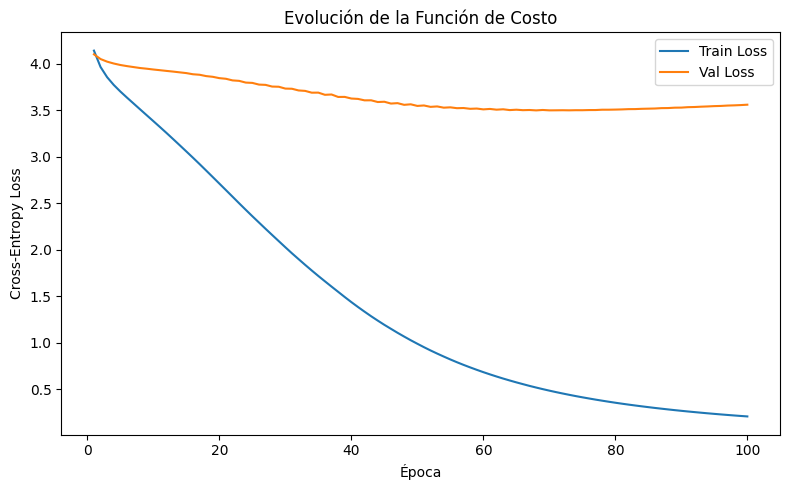

In [234]:
import numpy as np
import matplotlib.pyplot as plt
from src.Neural_Network import NeuralNetwork  


# Parámetros de M0
input_size    = X_train.shape[1]
hidden1, hidden2 = 100, 80
n_classes     = int(np.max(y_train)) + 1
epochs        = 100

# One-hot encoding
Y_train_oh = np.eye(n_classes)[y_train]
Y_val_oh   = np.eye(n_classes)[y_val]


M0 = NeuralNetwork(
    layer_sizes=[input_size, hidden1, hidden2, n_classes],
    learning_rate=0.11,
    seed=SEED
)

train_losses, val_losses = M0.train(
    X_train, Y_train_oh,
    X_val= X_val, Y_val=Y_val_oh,
    epochs=epochs,
    plot=True
)


### Métricas en Conjunto de Entrenamiento
**Accuracy:** 1.0000  
**Cross-Entropy Loss:** 0.2002  


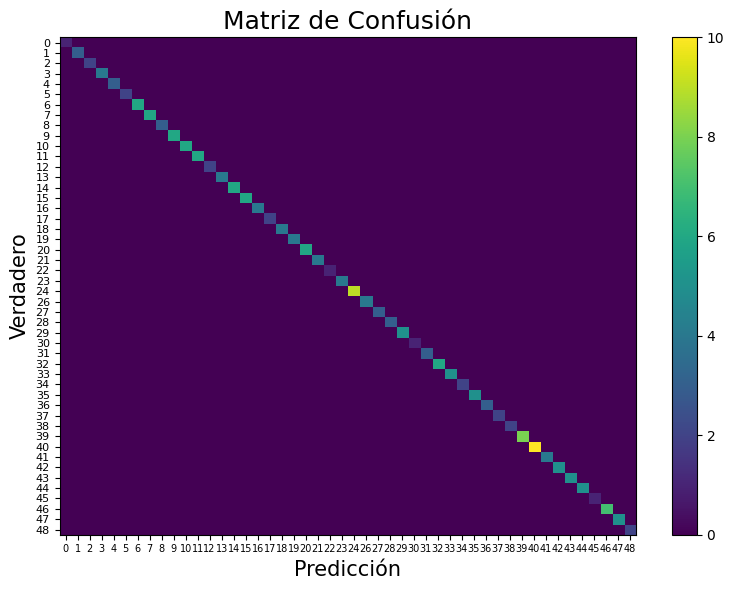

### Métricas en Conjunto de Validación
**Accuracy:** 0.2412  
**Cross-Entropy Loss:** 3.5597  
**Matriz de Confusión:**  
|True\Pred|0|1|2|3|4|5|6|7|8|9|10|11|12|13|14|15|16|17|18|19|20|21|22|23|24|25|26|27|28|29|30|31|32|33|34|35|36|37|38|39|40|41|42|43|44|45|46|47|48|
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
|0|0|0|0|0|1|0|1|0|1|0|0|0|1|0|2|0|1|1|1|0|1|0|0|0|1|0|0|0|0|0|0|0|0|3|0|0|0|0|0|0|0|0|3|0|1|0|0|1|0|
|1|0|3|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|1|0|0|0|0|0|4|6|0|0|0|0|0|0|0|1|0|0|1|0|0|0|0|0|3|0|0|1|0|1|0|0|
|2|0|0|10|0|0|3|1|0|0|0|0|2|0|0|0|3|0|0|0|0|0|8|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|
|3|0|0|0|7|0|0|0|1|0|0|0|0|0|0|1|0|0|0|1|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|
|4|0|0|0|0|9|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|0|0|1|1|0|0|0|0|2|0|0|0|0|0|0|0|0|0|1|0|1|0|0|0|0|0|0|0|
|5|0|0|1|0|1|1|2|0|0|0|1|1|0|0|0|0|0|0|0|1|0|0|0|1|1|0|0|0|0|1|0|0|0|1|3|0|0|1|0|6|1|0|0|0|0|0|1|0|0|
|6|0|0|1|0|0|1|4|0|0|1|0|0|0|0|0|2|0|0|0|1|1|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|3|0|0|0|0|0|0|0|0|
|7|0|0|0|0|0|0|1|3|0|1|0|0|0|0|0|0|0|0|1|0|0|0|0|0|1|0|0|0|1|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|2|
|8|0|0|0|0|1|0|1|0|1|0|0|0|0|1|0|2|1|0|0|0|1|0|0|0|1|0|0|0|0|0|0|0|2|1|1|0|3|0|0|1|1|0|0|1|0|0|0|0|0|
|9|0|1|0|0|0|0|0|0|0|12|0|1|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|1|0|1|0|0|0|0|1|0|
|10|0|0|0|0|0|0|0|0|0|3|5|2|0|0|0|8|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|
|11|0|0|0|1|0|0|1|0|0|1|0|13|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|
|12|0|0|0|0|0|0|0|0|0|0|2|2|3|3|0|0|0|0|0|1|0|1|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|1|0|0|2|0|0|0|0|0|
|13|0|0|0|0|0|0|2|0|0|0|0|0|0|7|2|0|0|0|0|0|0|0|0|0|1|0|0|0|1|2|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|
|14|0|0|0|0|0|0|1|0|0|0|0|0|0|0|11|0|0|0|0|1|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|1|0|0|
|15|0|0|0|0|0|0|1|1|0|4|1|0|0|0|1|6|0|0|0|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|3|0|0|0|0|0|0|0|0|
|16|0|0|0|0|0|1|0|0|0|0|0|0|1|0|0|0|1|0|0|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|1|4|0|1|0|0|0|0|0|0|
|17|0|0|0|0|1|0|1|0|1|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|10|0|0|0|0|1|0|0|0|0|0|3|0|0|0|0|0|0|0|1|0|0|0|0|0|
|18|0|0|0|1|0|0|1|3|0|0|1|2|0|0|0|0|0|0|4|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|0|0|0|0|0|0|2|0|0|
|19|0|0|0|1|0|0|1|0|0|5|0|5|2|0|0|0|0|0|0|2|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|1|0|
|20|0|0|0|0|0|0|0|1|0|0|0|0|0|0|2|0|0|0|0|0|3|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|6|0|0|0|0|0|3|0|0|
|21|0|0|0|0|0|1|0|0|0|4|0|0|0|0|0|2|0|0|1|0|0|5|0|0|0|0|1|0|0|1|0|0|1|1|0|0|0|0|0|0|0|1|0|1|0|0|0|1|0|
|22|0|0|0|0|0|0|0|0|2|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|4|0|0|0|0|0|0|0|0|0|0|0|0|0|0|4|0|1|1|0|2|0|0|0|0|
|23|0|0|0|0|0|0|1|0|0|0|1|0|0|0|0|3|0|0|0|0|3|0|0|3|1|0|1|1|0|0|0|0|1|1|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|
|24|0|2|0|1|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|13|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|
|25|0|1|0|0|2|0|0|2|0|0|0|0|0|0|0|0|0|0|1|1|0|0|0|0|4|0|0|0|0|0|0|0|1|0|0|2|0|0|0|0|0|1|0|1|0|0|0|0|0|
|26|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|1|0|3|0|0|1|0|0|1|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|
|27|0|0|0|0|0|0|0|0|0|0|1|0|0|0|0|2|0|0|0|0|0|1|0|0|1|0|0|5|0|0|0|0|0|0|0|0|0|0|0|2|0|0|0|0|0|0|0|0|0|
|28|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|1|0|0|0|0|0|9|0|0|0|0|1|0|0|0|0|0|0|1|0|
|29|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|2|0|0|0|0|2|0|0|1|0|0|0|0|0|0|0|0|1|0|0|0|0|1|0|0|
|30|0|0|0|0|0|0|4|0|0|3|0|5|0|0|0|2|0|0|0|0|0|1|0|0|2|0|0|0|0|0|0|0|0|0|0|0|0|1|0|2|0|0|0|4|0|0|0|0|0|
|31|0|0|1|0|0|0|0|0|0|5|0|0|2|0|1|0|0|0|0|2|0|0|0|0|0|0|0|0|0|0|0|4|0|0|0|0|0|0|0|1|0|0|1|0|0|0|0|0|0|
|32|0|2|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|0|0|0|1|0|1|0|0|1|0|0|3|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|
|33|0|0|0|0|0|0|0|0|0|0|0|0|0|0|3|0|0|0|0|0|0|0|0|0|4|0|0|0|0|1|0|0|0|3|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|
|34|0|0|0|1|0|0|0|1|0|0|0|1|0|0|1|1|0|0|2|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|0|1|0|0|0|0|0|
|35|0|1|0|0|2|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|6|0|0|1|0|0|0|0|0|1|0|3|0|0|0|5|1|0|0|0|0|0|0|0|0|
|36|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|2|0|0|0|0|0|3|0|2|0|0|0|0|0|0|0|0|0|0|0|0|2|0|0|0|1|0|0|0|0|0|0|0|0|
|37|0|0|0|0|0|0|0|2|0|3|0|6|0|0|0|1|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|0|0|2|0|0|0|0|0|1|0|0|
|38|0|0|1|0|0|7|0|0|0|1|0|2|0|0|0|0|3|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|2|0|0|0|0|0|0|0|0|
|39|0|0|1|0|0|3|0|0|0|0|0|0|0|1|0|6|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|0|0|0|0|2|1|0|0|0|0|0|1|0|0|
|40|0|0|3|0|0|2|1|0|0|1|0|0|0|0|0|0|1|0|0|0|1|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|4|1|0|1|0|0|0|1|0|
|41|0|1|0|0|0|0|2|0|1|3|1|0|0|0|1|2|0|0|1|3|0|1|0|1|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|1|2|0|0|0|1|0|0|0|
|42|0|0|0|0|0|1|0|0|0|0|1|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0|8|0|0|0|0|0|0|
|43|0|0|0|0|0|0|0|1|0|1|0|1|0|0|0|1|0|0|1|1|0|1|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|5|0|0|0|0|0|
|44|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0|0|1|2|0|4|0|0|1|0|
|45|0|0|0|0|0|0|1|0|0|1|0|0|0|0|0|2|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|2|0|0|0|0|0|0|0|0|0|0|1|0|1|0|0|
|46|0|0|0|0|1|1|2|0|0|0|1|0|1|0|0|0|1|0|0|0|2|0|0|0|2|0|0|1|0|1|0|0|0|1|0|0|0|0|0|3|0|0|0|0|0|0|10|0|0|
|47|0|0|0|0|0|0|0|1|0|3|0|0|0|0|0|0|0|0|1|0|1|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|1|0|0|2|0|1|0|0|2|0|
|48|0|0|0|0|0|2|0|3|0|1|0|1|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|1|1|0|0|0|0|0|0|0|1|


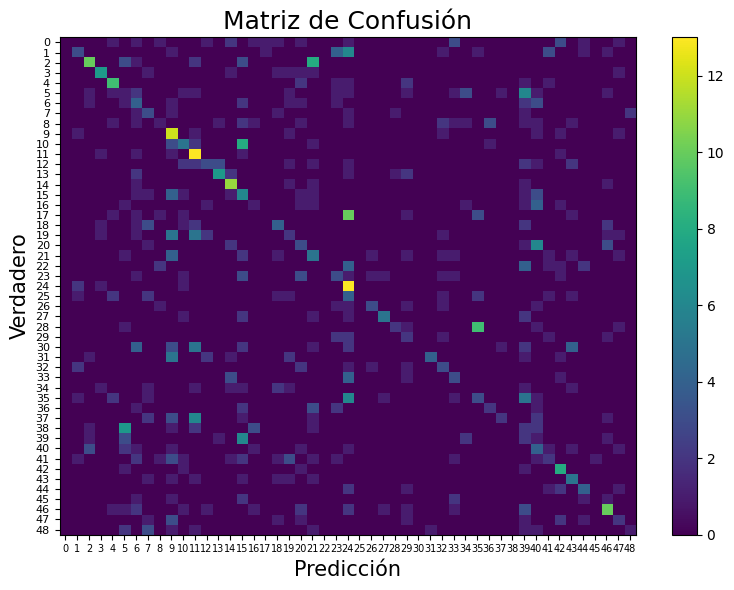

In [ ]:

from src.metrics import Metrics  # importa la clase que guardaste en metrics.py

# 1) Calcula predicciones “duro” (etiquetas) y predicciones “blando” (probabilidades)

Y_hat_train = M0.forward(X_train)      # shape (n_classes, m_train)
y_proba_train = Y_hat_train.T          # shape (m_train, n_classes)
y_pred_train  = np.argmax(Y_hat_train, axis=0)  # shape (m_train,)

#    – Para validación:
Y_hat_val   = M0.forward(X_val)        # shape (n_classes, m_val)
y_proba_val = Y_hat_val.T              # shape (m_val, n_classes)
y_pred_val  = np.argmax(Y_hat_val, axis=0)      # shape (m_val,)

# 2) Crea y muestra las métricas con la clase Metrics
#    Puedes pasarle también la lista de labels si quieres un orden específico;
#    si no, los infiere de y_true/y_pred.

# Métricas en entrenamiento
met_train = Metrics(
    y_true=y_train,
    y_pred=y_pred_train,
    y_proba=y_proba_train
)
met_train.report_metrics(title="Métricas en Conjunto de Entrenamiento", show_matrix_table = True, plot_matrix_heatmap= True)

# Métricas en validación
met_val = Metrics(
    y_true=y_val,
    y_pred=y_pred_val,
    y_proba=y_proba_val
)
met_val.report_metrics(title="Métricas en Conjunto de Validación")
